### Bài toán hồi quy tuyến tính (Liner Regression)

Vẽ đường thẳng $y = wx + b$ 



In [11]:
import numpy as np # type: ignore

In [12]:
class Activation:
    @staticmethod
    def func(x):
        return x
    @staticmethod
    def derivative(x):
        return 1

In [13]:
class Loss:
    @staticmethod
    def func(y_hat, y_true):
        return np.sum((y_hat - y_true) ** 2) / 2
    @staticmethod
    def derivative(y_hat, y_true):
        return y_hat - y_true


In [14]:
class Layer:
    def __init__(self, input_size, output_size, actFunc):
        self.input_size = input_size
        self.output_size = output_size
        self.W =  np.random.randn(input_size, output_size) * 0.01
        self.b = np.ones((1, output_size))
        self.act = actFunc
        self.X = None
        self.Z = None
        self.A = None
        
    def forward(self, input):
        self.X = input
        self.Z = self.X @ self.W + self.b
        self.A = self.act.func(self.Z)
        return self.A

    def backward(self, alpha, dL_dA):
        dL_dZ = dL_dA * self.act.derivative(self.Z)
        dL_dX = dL_dZ @ self.W.T
        dL_dW = self.X.T @ dL_dZ
        dL_db = np.sum(dL_dZ, axis=0, keepdims=True)
        self.W -= alpha * dL_dW
        self.b -= alpha * dL_db
        return dL_dX
    
    def show(self):
        print("W = ")
        print(self.W)
        print(f"b = {self.b}")

In [15]:
class Model:
    def __init__(self, learning_rate, layer_size, lossFunc):
        self.alpha = learning_rate
        self.lossFunc = lossFunc
        self.y_hat = None
        self.layers = []
        for i in range(len(layer_size) - 1):
            layer = Layer(layer_size[i], layer_size[i + 1], Activation())
            self.layers.append(layer)

    def forward(self, x):
        for i in range(len(self.layers)):
            x = self.layers[i].forward(x)
        self.y_hat = x
        return x
    
    def backward(self, y_true):
        dL_dY = Loss.derivative(self.y_hat, y_true)
        for i in range(len(self.layers) - 1, -1, -1):
            dL_dY = self.layers[i].backward(self.alpha, dL_dY)

    def train(self, dataset, max_iter):
        x = dataset[:, :-1]
        y_true = dataset[:, -1].reshape(-1, 1)
        history = []
        for i in range(max_iter):
            self.forward(x)
            loss = Loss.func(self.y_hat, y_true)
            history.append(loss) 
            self.backward(y_true)
        return history
    
    def show(self):
        for i in range(len(self.layers)):
            print(f"Layer {i + 1}")
            self.layers[i].show()
            print()



In [16]:
dataset = np.array([[1, 2], [3, 3], [5, 4], [7, 5], [9, 6]])

learning_rate = 0.01
layer_size = [1, 1]
lossFunc = Loss()

model = Model(learning_rate, layer_size, lossFunc)
history = model.train(dataset, 200)

In [17]:
for i in range(len(history)):
    print(f"Generation {i}, loss = {history[i]:.2f}")

Generation 0, loss = 27.99
Generation 1, loss = 13.31
Generation 2, loss = 6.35
Generation 3, loss = 3.06
Generation 4, loss = 1.50
Generation 5, loss = 0.76
Generation 6, loss = 0.40
Generation 7, loss = 0.24
Generation 8, loss = 0.16
Generation 9, loss = 0.12
Generation 10, loss = 0.10
Generation 11, loss = 0.09
Generation 12, loss = 0.08
Generation 13, loss = 0.08
Generation 14, loss = 0.07
Generation 15, loss = 0.07
Generation 16, loss = 0.07
Generation 17, loss = 0.07
Generation 18, loss = 0.07
Generation 19, loss = 0.07
Generation 20, loss = 0.06
Generation 21, loss = 0.06
Generation 22, loss = 0.06
Generation 23, loss = 0.06
Generation 24, loss = 0.06
Generation 25, loss = 0.06
Generation 26, loss = 0.06
Generation 27, loss = 0.05
Generation 28, loss = 0.05
Generation 29, loss = 0.05
Generation 30, loss = 0.05
Generation 31, loss = 0.05
Generation 32, loss = 0.05
Generation 33, loss = 0.05
Generation 34, loss = 0.05
Generation 35, loss = 0.04
Generation 36, loss = 0.04
Generatio

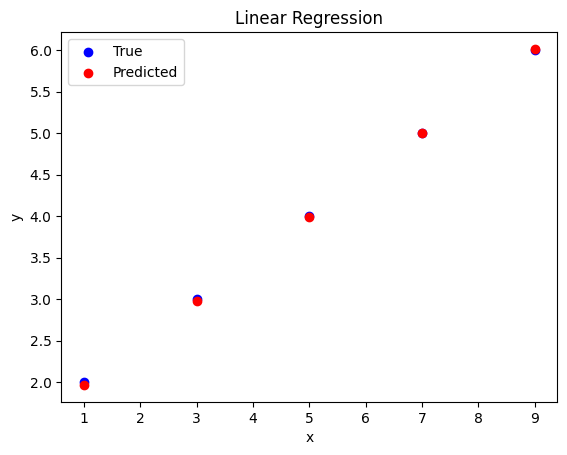

In [ ]:
# visualization
import matplotlib.pyplot as plt # type: ignore
x = dataset[:, :-1]
y_true = dataset[:, -1]
y_pred = model.forward(x)

# vẽ đường thẳng dự đoán và điểm dữ liệu thực tế

plt.scatter(x, y_true, color='blue', label='True')
plt.scatter(x, y_pred, color='red', label='Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.show()